# Medical Images Project
---

**RadCTTACEomics_1447**

- Reference image: 11_AP_Ax5.00mm

3D Image Segmentation


In [21]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy import ndimage as ndi
from skimage.feature import canny,peak_local_max
from skimage.filters import gaussian, sobel
from skimage.segmentation import watershed, mark_boundaries
from skimage.measure import regionprops, label, find_contours
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score, cohen_kappa_score
from skimage.morphology import  binary_dilation,binary_erosion, ball
import pywt
from matplotlib.colors import BoundaryNorm
import napari

To facilitate more efficient progress in this task, the liver and tumor masks already rescaled to the original images are used, together with the reference images that exhibit superior contrast.

In [2]:
# Arrays
file_gt_liver='gt_liver_mask.npy'
file_gt_tumor='gt_tumor_mask.npy'
file_ref_img='windowed_ct_images.npy'
file_aspect_ratio='ratio.npy'
#ratio
path_array_folder='task2_data'
in_path = os.path.join(path_array_folder, file_gt_liver)
gt_liver_mask = np.load(in_path)
in_path = os.path.join(path_array_folder, file_gt_tumor)
gt_tumor_mask = np.load(in_path)
in_path = os.path.join(path_array_folder, file_ref_img)
ct_images = np.load(in_path)
in_path = os.path.join(path_array_folder, file_aspect_ratio)
ratios = np.load(in_path) # Positions axial_aspect_ratio, aspect_ratio_sagittal, aspect_ratio_coronal
aspect_ratio_axial=ratios[0]
aspect_ratio_coronal=ratios[1]
aspect_ratio_sagittal=ratios[2]

**Consider the Tumor mask associated to the reference image, and extract its bounding box and centroid.**  

---
As a result of the findings derived from objective one, it has been established that the tumor mask contains multiple tumors. To facilitate the subsequent tasks, it is necessary to separate them.

In [3]:
def split_components_3d(mask):
    # Verify that the input is a binary 3D mask
    if mask.ndim != 3:
        raise ValueError('The mask must be three-dimensional (3D).')
    
    if mask.dtype != np.uint8:
        raise ValueError('The mask must be uint8 type')
    
    if not np.all(np.isin(mask, [0, 1])):
        raise ValueError('The mask must contain only 0 and 1 values.')
    
    # label connected components
    # structure=np.ones((3,3,3)) defines 3D connectivity (26-connectivity)
    labels, components_amount = ndi.label(mask, structure=np.ones((3,3,3)))
    
    # Create a separate mask for each component
    individuals_mask = []
    for i in range(1, components_amount + 1):
        mask_componente = np.zeros_like(mask)
        mask_componente[labels == i] = 1
        individuals_mask.append(mask_componente)
    
    print(f'Connected {components_amount} components found')
    return individuals_mask

individuals_mask=split_components_3d(gt_tumor_mask)

Connected 3 components found


In [4]:
def obtain_3d_bbox(tumor_mask, idx):
    coords = np.argwhere(tumor_mask > 0)
    z_coords, y_coords, x_coords = coords[:, 0], coords[:, 1], coords[:, 2]
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    z_min, z_max = np.min(z_coords), np.max(z_coords)
    print(f'Mask {idx} Bounding box: z_min {z_min}, y_min {y_min}, x_min {x_min}, z_max {z_max}, y_max {y_max}, x_max {x_max}')
    return (z_min, y_min, x_min, z_max, y_max, x_max)

def show_3d_centroid(tumor_mask, idx):
    coords = np.argwhere(tumor_mask > 0)
    z_coords, y_coords, x_coords = coords[:, 0], coords[:, 1], coords[:, 2]
    centroid = (np.mean(z_coords),np.mean(y_coords), np.mean(x_coords))
    print(f'Mask {idx} Centroid z {centroid[0]}, y {centroid[1]}, x {centroid[2]}')
    return centroid

In [5]:
bbox=[]
centroids=[]
for i in range(len(individuals_mask)):
    bbox.append(obtain_3d_bbox(individuals_mask[i],i))
    centroids.append(show_3d_centroid(individuals_mask[i],i))
    print('----------------------------------------------------------------------')

Mask 0 Bounding box: z_min 11, y_min 203, x_min 140, z_max 14, y_max 221, x_max 164
Mask 0 Centroid z 12.80070754716981, y 211.6615566037736, x 152.14268867924528
----------------------------------------------------------------------
Mask 1 Bounding box: z_min 18, y_min 106, x_min 243, z_max 23, y_max 132, x_max 264
Mask 1 Centroid z 20.48323793949305, y 120.54619787408014, x 253.04578904333607
----------------------------------------------------------------------
Mask 2 Bounding box: z_min 25, y_min 223, x_min 100, z_max 27, y_max 236, x_max 111
Mask 2 Centroid z 25.804878048780488, y 230.22357723577235, x 105.65447154471545
----------------------------------------------------------------------


**Create a semi-automatic tumor segmentation algorithm that only uses the CT image, and
either the bounding box or the centroid of the tumor.**

---


In this segmentation, either centroids or ground truth bounding boxes can be used. Medical detection methods prioritize reducing false negatives (i.e. increasing sensitivity), since it is usually much worse than performing additional tests on healthy people due to false positives to fail to detect a disease.

An attempt was made to use the centroid with the Hessian, Canny, and centroid method (a protracted process). The bounding box was employed instead of the Hessian, which was also excessively time-consuming (centroid). The outcome of both these attempts was found to be null, with the Specificity set at 1 and the remainder at 0.

Watershed has been chosen as it is particularly useful when bounding boxes and edge maps (Canny) are available to delineate tumor contours quickly and effectively. Preprocessing with sharpening was also attempted, but this resulted in a reduction of the overall metrics by tenths of a degree. Adding morphological methods adjusted the result, because without them a half-filled area was created, leaving part of the tumor exposed. Additionally, we have increased the z-axis limit due to previously systematically detecting tumors located at the bounding box's z-limit.

In [6]:
def segment_bounding_box_3d(arr, bbox, canny_sigma=1.5):
    '''
    Segment a region in a 3D numpy array using 3D Canny edge detection (applied per axis and combined) and 3D watershed.
    '''
    z_min, y_min, x_min, z_max, y_max, x_max = bbox
    z_max+=1
    sub = arr[z_min:z_max, y_min:y_max, x_min:x_max]

    # Combine Canny edges along each axis
    # Canny is 2D; run along each axis and combine
    # The edges detected in each slice are combined into a single boolean array edges.
    edges = np.zeros_like(sub, dtype=bool)
    # ZY plane (for each X)
    for x in range(sub.shape[2]):
        edges[..., x] |= canny(sub[..., x], sigma=canny_sigma)
    # ZX plane (for each Y)
    for y in range(sub.shape[1]):
        edges[:, y, :] |= canny(sub[:, y, :], sigma=canny_sigma)
    # YX plane (for each Z)
    for z in range(sub.shape[0]):
        edges[z, ...] |= canny(sub[z, ...], sigma=canny_sigma)
    # Now edges is a 3D mask of detected edges
    # 3D Gradient (Sobel) for watershed elevation map
    # Highlighting regions of rapid intensity change
    elevation_map = np.sqrt(
        sum(np.square(ndi.sobel(sub, axis=i)) for i in range(3))
    )

    # watershed segmentation using the elevation map and markers derived from the edges
    # Invert edges for marker labeling (watershed grows from non-edges)
    markers, _ = ndi.label(~edges)

    # Mask for the region (avoid growing into background)
    mask_fg = sub > np.percentile(sub, 22)

    seg = watershed(elevation_map, markers, mask=mask_fg)

    # Select largest non-background region
    region_labels, region_counts = np.unique(seg, return_counts=True)
    if len(region_labels) > 1:
        # skip 0 (background)
        region_labels = region_labels[1:]  
        region_counts = region_counts[1:]
        largest_region = region_labels[np.argmax(region_counts)]
        mask_sub = seg == largest_region
    else:
        mask_sub = np.zeros_like(sub, dtype=bool)

    # Remove small objects in 3D
    # Using the structure for 3D images 
    mask_sub=binary_erosion(mask_sub,ball(1))
    mask_sub=binary_dilation(mask_sub,ball(2))
    mask_sub=ndi.binary_fill_holes(mask_sub)
    mask_sub=binary_erosion(mask_sub,ball(1))
    # Place the mask back into the full array
    mask = np.zeros_like(arr, dtype=bool)
    mask[z_min:z_max, y_min:y_max, x_min:x_max] = mask_sub

    return mask

In [7]:
segmentations=[]
for i in range(len(bbox)):
    segmentation=segment_bounding_box_3d(ct_images,bbox[i])
    segmentations.append(segmentation)
        

**Visualize both the provided Tumor mask and the segmented Tumor mask on the image.
Assess the correctness of the algorithm, numerically and visually**

---
Visualization section

For the tumor mask used to create and test the algorithm here is the data to check the slices where each ground truth is located.
- 0 Slice 11 
- 1 Slice 12
- 2 Slice 13 
- 3 Slice 14 
- 4 Slice 18:
- 5 Slice 19
- 6 Slice 20
- 7 Slice 21
- 8 Slice 22
- 9 Slice 23
- 10 Slice 25
- 11 Slice 26
- 12 Slice 27

Tumor slices fomr this array of certain slices:  
Ground truth 0, [0-3]  
Ground truth 1, [4-9]  
Ground truth 2, [10-12]

(-0.5, 511.5, 511.5, -0.5)

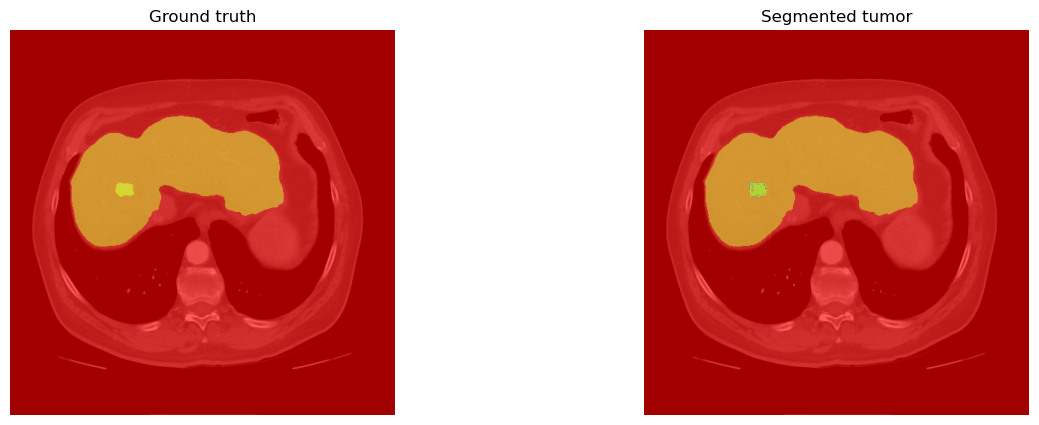

In [8]:
slices=[11,12,13,14,18,19,20,21,22,23,25,26,27]
len(slices)
slice_idx=2 #Idx for the array slices
ntumor=0 #Number of tumor is referred in individual_masks

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(ct_images[slices[slice_idx]], cmap='gray')
axes[0].imshow(individuals_mask[ntumor][slices[slice_idx]], cmap='autumn', alpha=0.4)
axes[0].imshow(gt_liver_mask[slices[slice_idx]], cmap='autumn', alpha=0.4)
axes[0].set_title('Ground truth')
axes[0].axis('off')
axes[1].imshow(ct_images[slices[slice_idx]], cmap='gray')
axes[1].imshow(segmentations[ntumor][slices[slice_idx]], cmap='prism', alpha=0.4)  
axes[1].imshow(gt_liver_mask[slices[slice_idx]], cmap='autumn', alpha=0.4)
axes[1].set_title('Segmented tumor')
axes[1].axis('off')

In [9]:
def find_tumor_slice(tumor_mask):
    # Find slices where the tumor appears in each plane.
    # Calculate the sum of the mask values in each direction
    z_sums = np.sum(tumor_mask, axis=(1, 2))
    y_sums = np.sum(tumor_mask, axis=(0, 2))
    x_sums = np.sum(tumor_mask, axis=(0, 1))
    
    # Find slices with tumor
    z_tumor_slices = np.where(z_sums > 0)[0]
    y_tumor_slices = np.where(y_sums > 0)[0]
    x_tumor_slices = np.where(x_sums > 0)[0]
    
    if len(z_tumor_slices) == 0 or len(y_tumor_slices) == 0 or len(x_tumor_slices) == 0:
        print('No tumor was found in any of the plans.')
        return  
    
    # Select central slices with tumor
    z_slice = z_tumor_slices[len(z_tumor_slices) // 2]
    y_slice = y_tumor_slices[len(y_tumor_slices) // 2]
    x_slice = x_tumor_slices[len(x_tumor_slices) // 2]    
    return z_slice,y_slice,x_slice

In [10]:
def visualize_segmentation_multiplanar(images, tumor_mask):
    '''
    Visualizes the CT image with the tumor mask superimposed in axial,
    coronal and sagittal planes. Automatically highlights slices where the tumor appears.
    '''
    z_slice,y_slice,x_slice=find_tumor_slice(tumor_mask)

    # Create a custom color map for the tumor (semi-transparent red).
    colors = [(1, 0, 0, 0), (1, 0, 0, 0.7)]  # Red transparent to semi-opaque red
    tumor_cmap = ListedColormap(colors, name='tumor_cmap')
    
    # Normalize images for display
    def normalize_image(img):
        img_min = np.min(img)
        img_max = np.max(img)
        return (img - img_min) / (img_max - img_min) if img_max > img_min else img
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.suptitle(f'Multiplanar display of detected tumor segmentation', fontsize=16)
    
    # Axial
    ax = axes[0]
    ax.imshow(normalize_image(images[z_slice]), cmap='gray')
    ax.imshow(tumor_mask[z_slice], cmap=tumor_cmap)
    ax.set_title(f'Axial (z={z_slice})', fontsize=14)
    ax.axis('off')
    
    # Coronal 
    ax = axes[1]
    ax.imshow(images[:, y_slice, :], cmap='gray')
    ax.imshow(tumor_mask[:, y_slice, :], cmap=tumor_cmap, aspect=aspect_ratio_coronal)
    ax.set_title(f'Coronal (y={y_slice})', fontsize=14)
    ax.axis('off')
    
    # Sagital
    ax = axes[2]
    ax.imshow(images[:, :, x_slice], cmap='gray')
    ax.imshow(tumor_mask[:, :, x_slice], cmap=tumor_cmap, aspect=aspect_ratio_sagittal)
    ax.set_title(f'Sagital (x={x_slice})', fontsize=14)
    ax.axis('off')  
    plt.show()

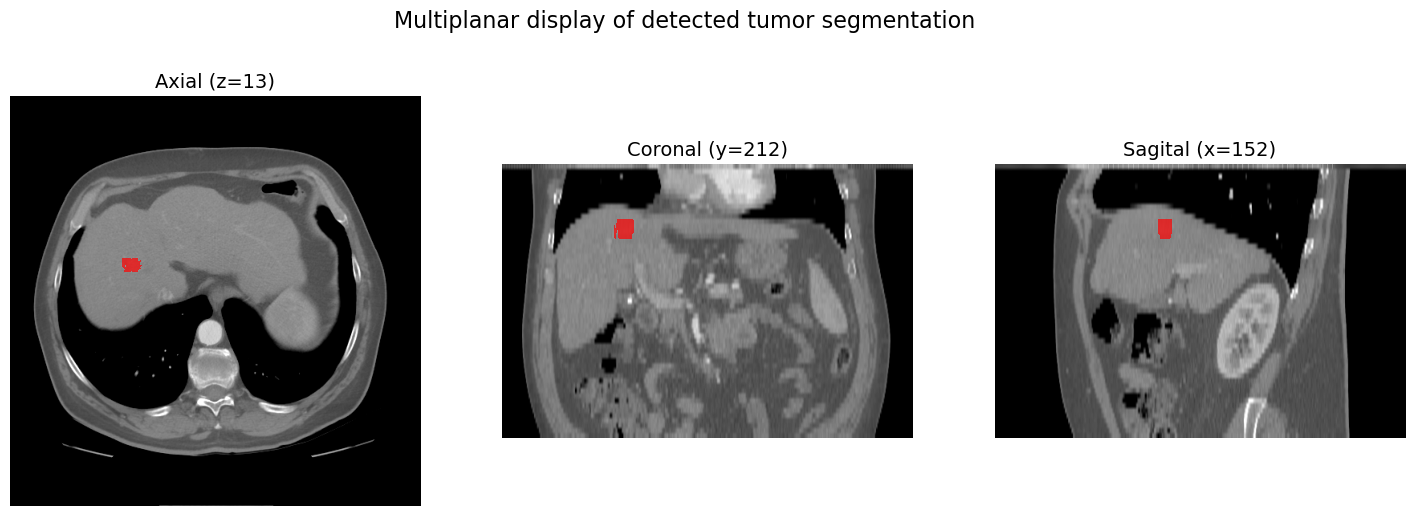

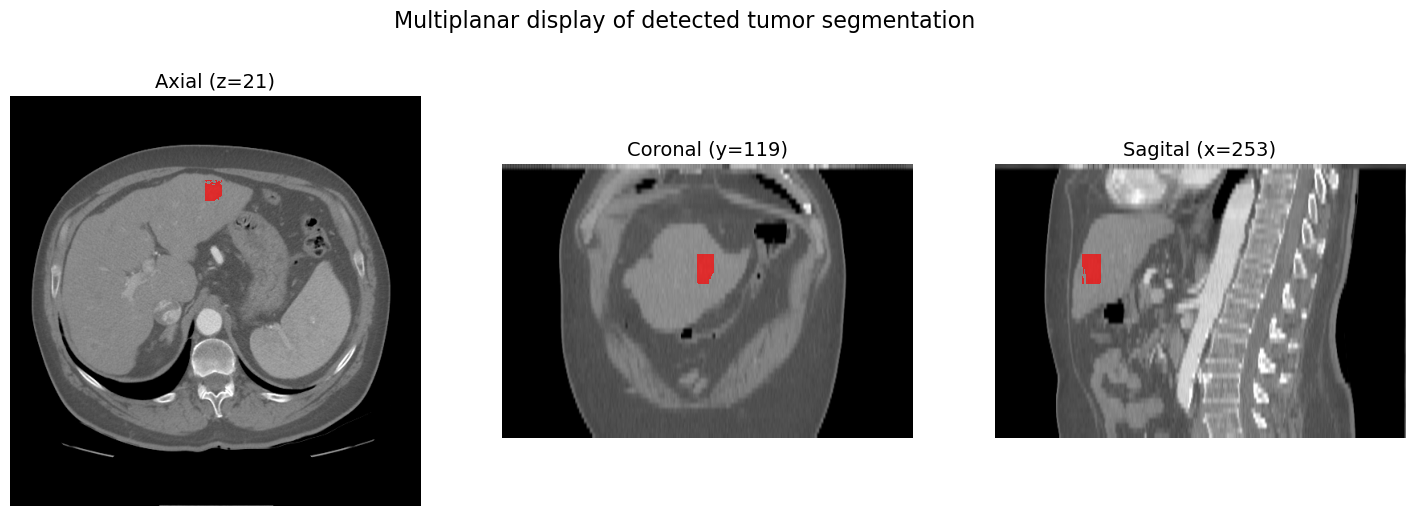

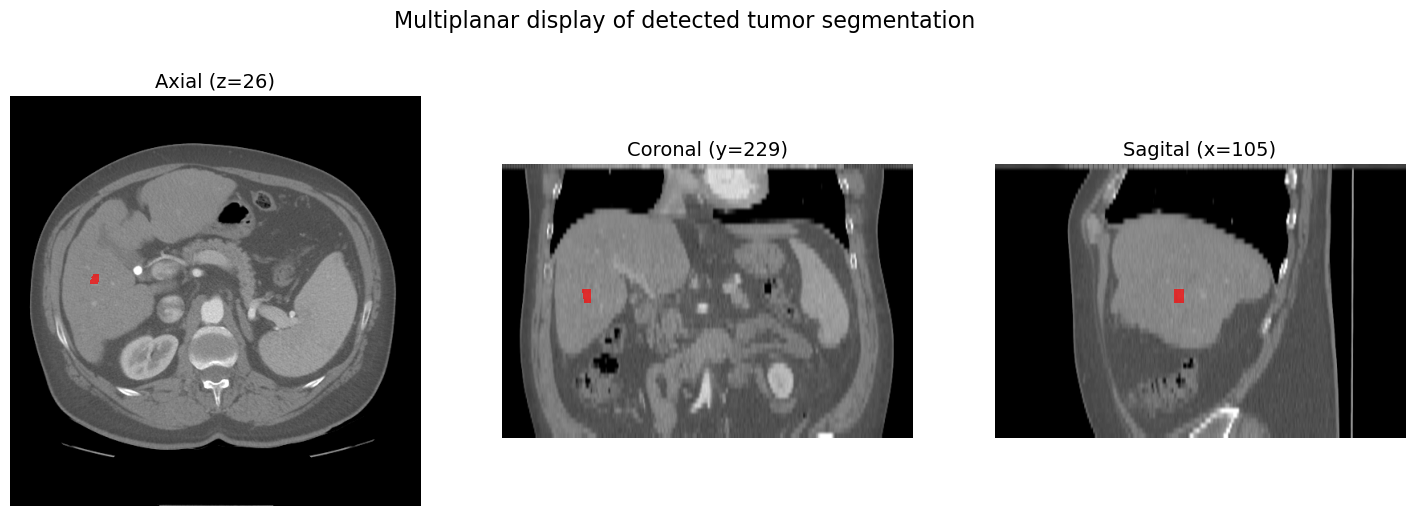

In [11]:
for i in range(len(segmentations)):
    visualize_segmentation_multiplanar(ct_images, segmentations[i])

In [12]:
def visualize_comparison_multiplanar(images, ground_truth, tumor_mask):
    '''
    Visualize the CT image with the ground truth mask and the segmented mask 
    automatically in axial, coronal and sagittal planes.
    '''
    # Search slices where any of the masks appear
    combined_mask = np.logical_or(ground_truth > 0, tumor_mask > 0)    
    z_slice,y_slice,x_slice=find_tumor_slice(combined_mask)
    
    gt_colors = [(0, 0, 0, 0), (0, 1, 0, 0.7)]  # green
    gt_cmap =  ListedColormap(gt_colors, name='gt_cmap')
    
    seg_colors = [(0, 0, 0, 0), (1, 0, 0, 0.7)]  # red 
    seg_cmap =  ListedColormap(seg_colors, name='seg_cmap')
    
    # Normalize images for display
    def normalize_image(img):
        img_min = np.min(img)
        img_max = np.max(img)
        return (img - img_min) / (img_max - img_min) if img_max > img_min else img
    

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.suptitle('Comparison of automatic segmentation and ground truth', fontsize=16)
    
    # Create color coded overlay masks
    # Values: 0=ground, 1=ground truth only, 2=segmentation only, 3=overlay
    def create_overlap_display(gt, seg):
        overlap = np.zeros_like(gt)
        overlap[gt > 0] = 1  # Green (only ground truth)
        overlap[seg > 0] += 2  # Add 2 where there is segmentation
        return overlap

    # Create overlay masks for each plane
    axial_overlap = create_overlap_display(ground_truth[z_slice], tumor_mask[z_slice])
    coronal_overlap = create_overlap_display(ground_truth[:, y_slice, :], tumor_mask[:, y_slice, :])
    sagittal_overlap = create_overlap_display(ground_truth[:, :, x_slice], tumor_mask[:, :, x_slice])
    

    # Create custom colormap for overlay display
    overlap_cmap = plt.cm.colors.ListedColormap(['black', 'green', 'red', 'yellow'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, overlap_cmap.N)
    
    # Axial 
    mask = axial_overlap > 0
    ax = axes[0]
    ax.imshow(images[z_slice], cmap='gray')
    ax.imshow(np.ma.masked_where(~mask, axial_overlap), cmap=overlap_cmap, norm=norm, alpha=0.7)
    ax.set_title(f'Axial (z={z_slice})', fontsize=14)
    ax.axis('off')
    
    # Plano Coronal
    mask = coronal_overlap > 0
    ax = axes[1]
    ax.imshow(images[:, y_slice, :], cmap='gray')
    ax.imshow(np.ma.masked_where(~mask, coronal_overlap), cmap=overlap_cmap, norm=norm, alpha=0.7, aspect=aspect_ratio_coronal)
    ax.set_title(f'Coronal (y={y_slice})', fontsize=14)
    ax.axis('off')
    
    # Sagittal 
    mask = sagittal_overlap > 0
    ax = axes[2]
    ax.imshow(images[:, :, x_slice], cmap='gray')
    ax.imshow(np.ma.masked_where(~mask, sagittal_overlap), cmap=overlap_cmap, norm=norm, alpha=0.7, aspect=aspect_ratio_sagittal)
    ax.set_title(f'Sagital (x={x_slice})', fontsize=14)
    ax.axis('off')
    
    
    # Add legend
    legend_elements = [
        mpatches.Patch(color='green', label='Ground Truth', alpha=0.7),
        mpatches.Patch(color='red', label='Segmentation', alpha=0.7),
        mpatches.Patch(color='yellow', label='Overlay', alpha=0.7)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.14)    
    plt.show()

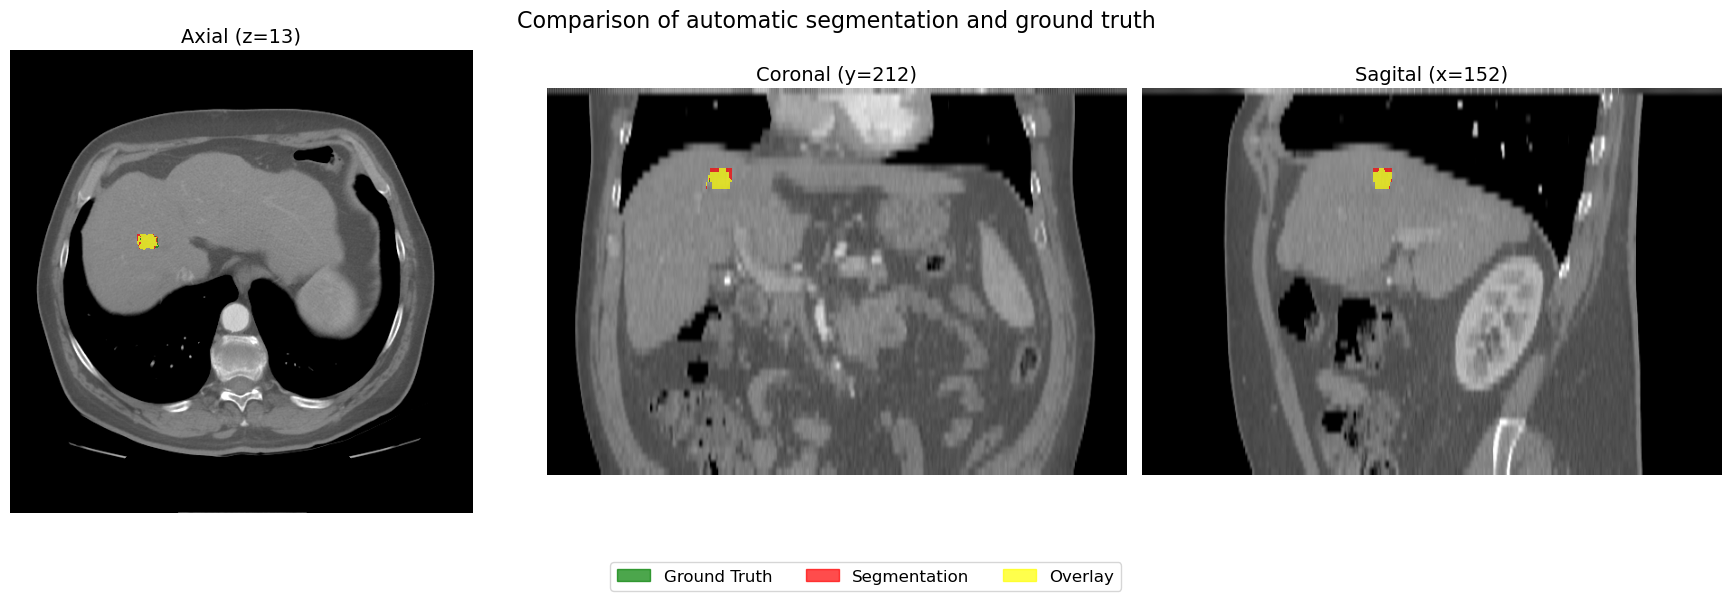

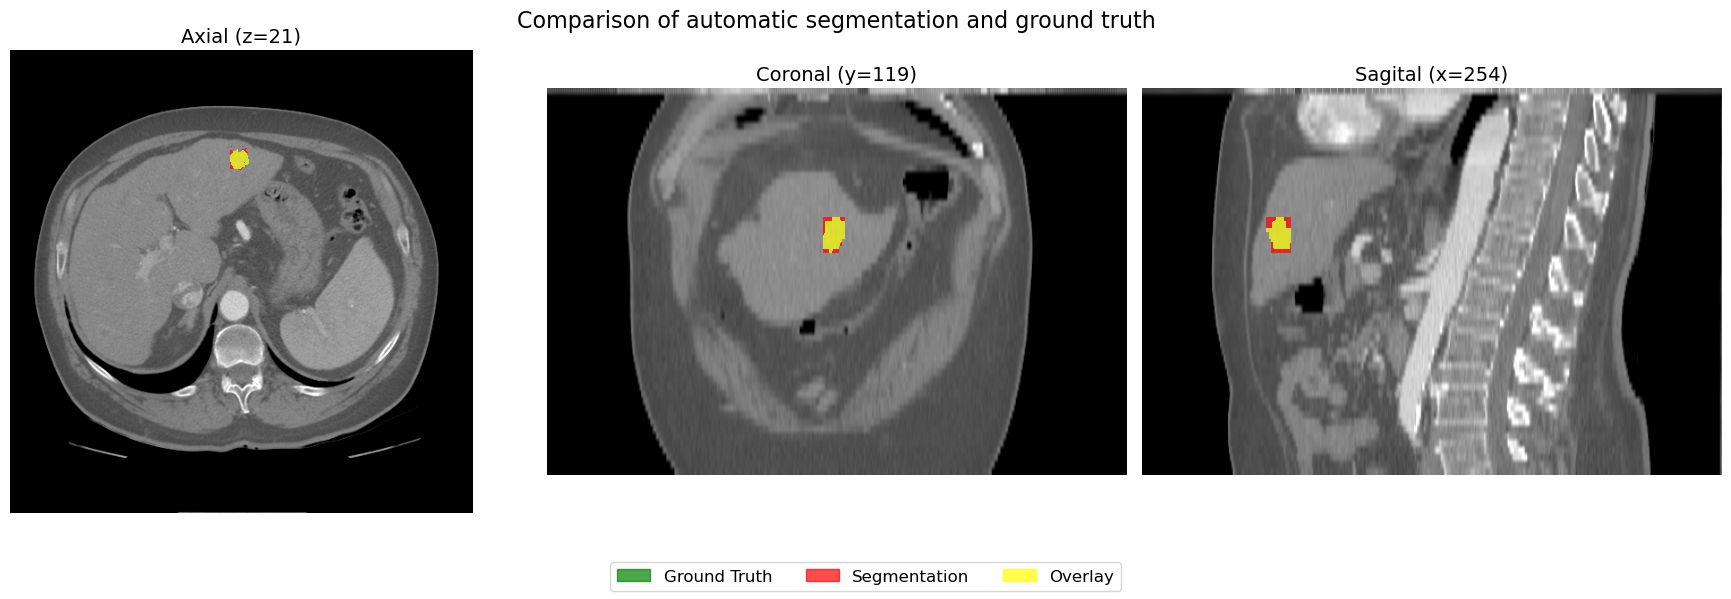

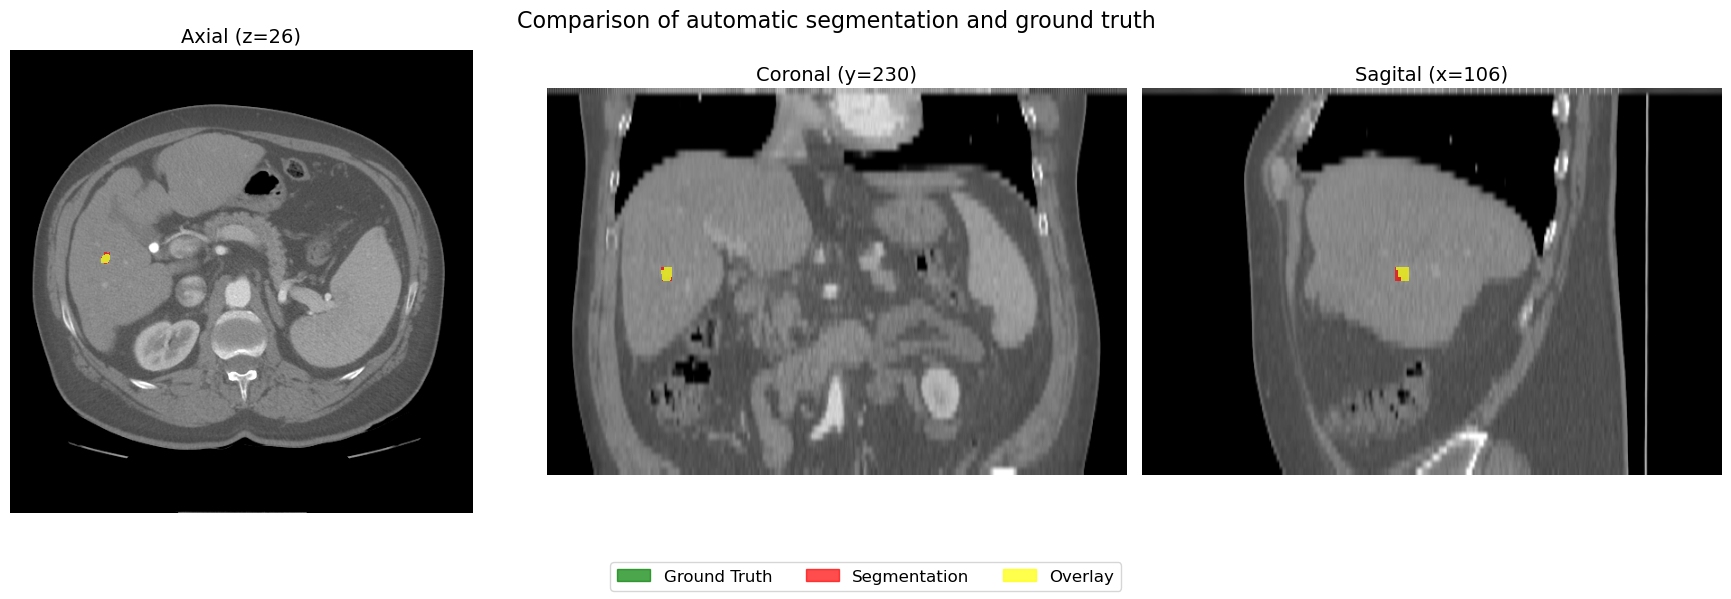

In [13]:
for i in range(len(segmentations)):
    visualize_comparison_multiplanar(ct_images, individuals_mask[i],segmentations[i])

To do dynamic visualization the following code uses Napari. It is similar to 3D Slicer, however it is more simplistic. Interesting links: [Intro](https://ilovesymposia.com/2019/10/24/introducing-napari-a-fast-n-dimensional-image-viewer-in-python/), [Voxel Size](https://forum.image.sc/t/changing-the-voxel-size-in-napari/31818)

In [19]:
for i in range(len(individuals_mask)):
    viewer = napari.Viewer()
    viewer.add_image(ct_images, name='Original')
    viewer.add_labels(individuals_mask[i], name='Ground Truth')
    viewer.add_labels(segmentations[i], name='Segmentation')
    napari.run()

In the following images, dark blue is the ground truth, and the segmentation color changes depending on the tumor.

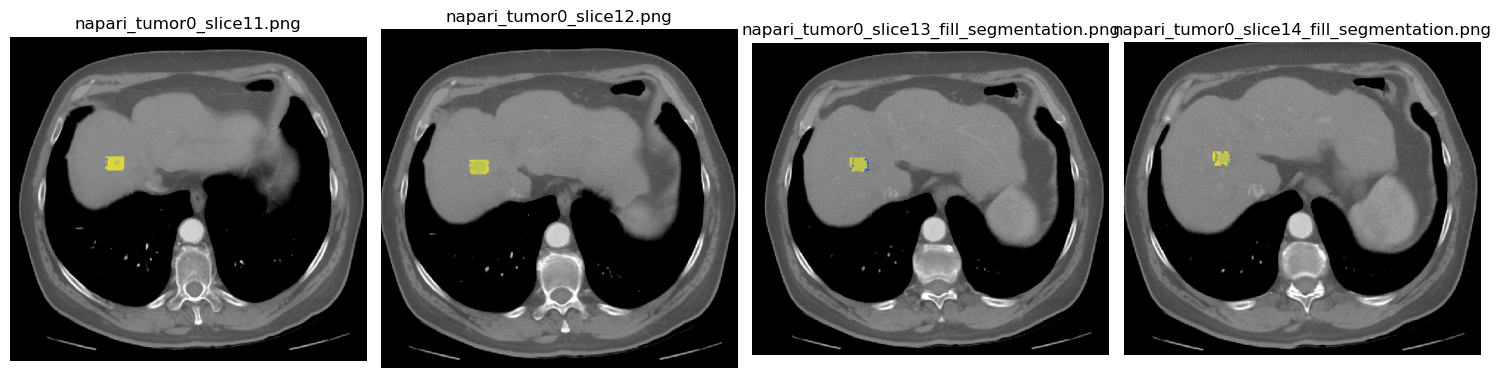

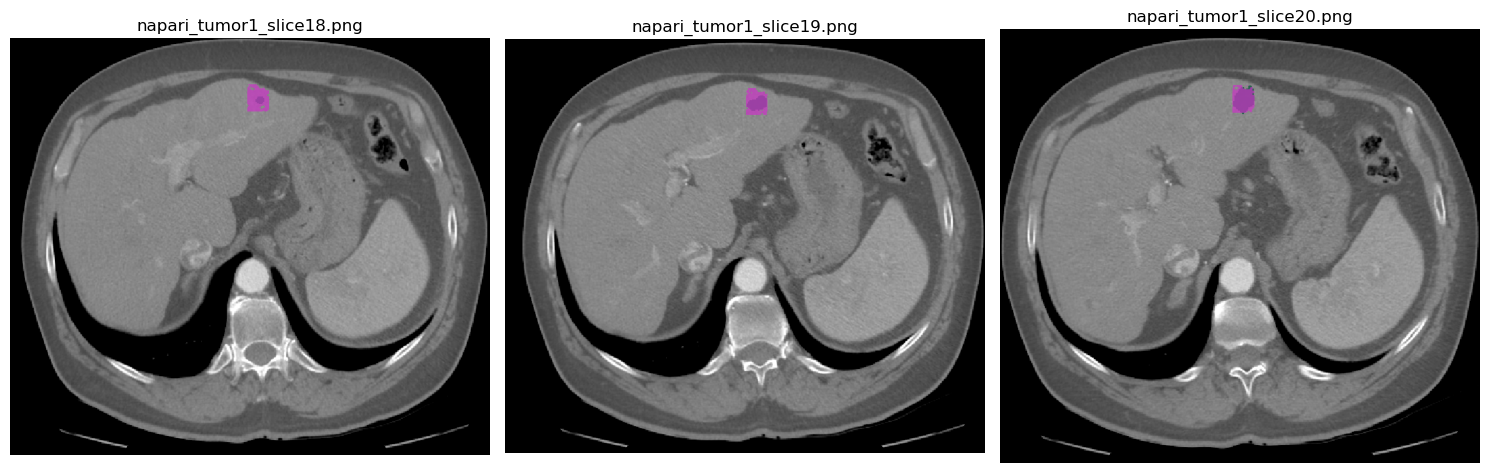

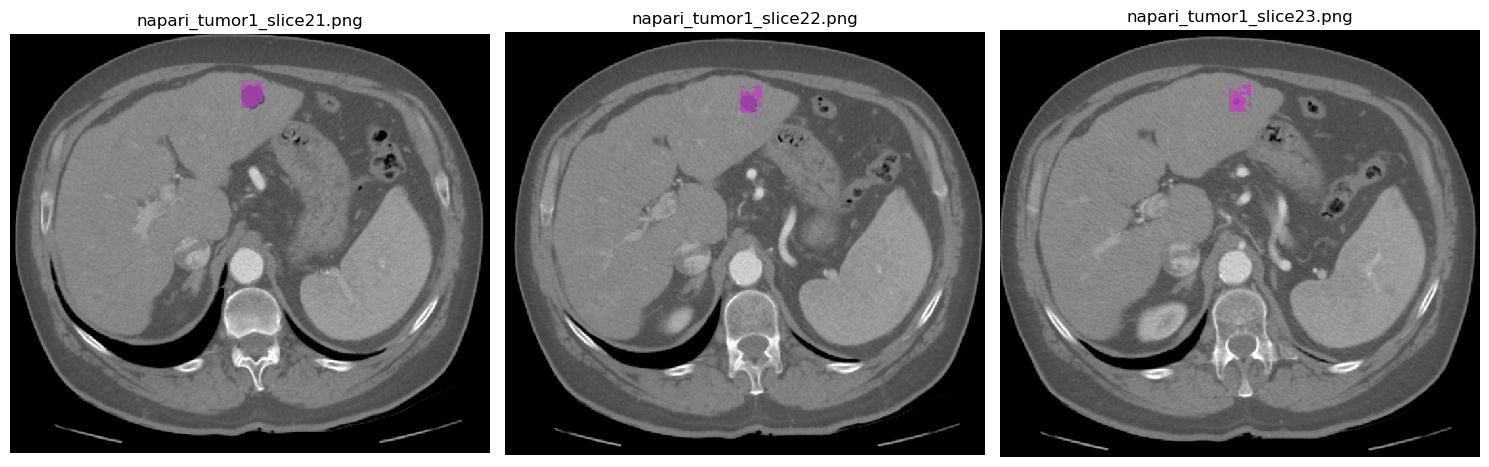

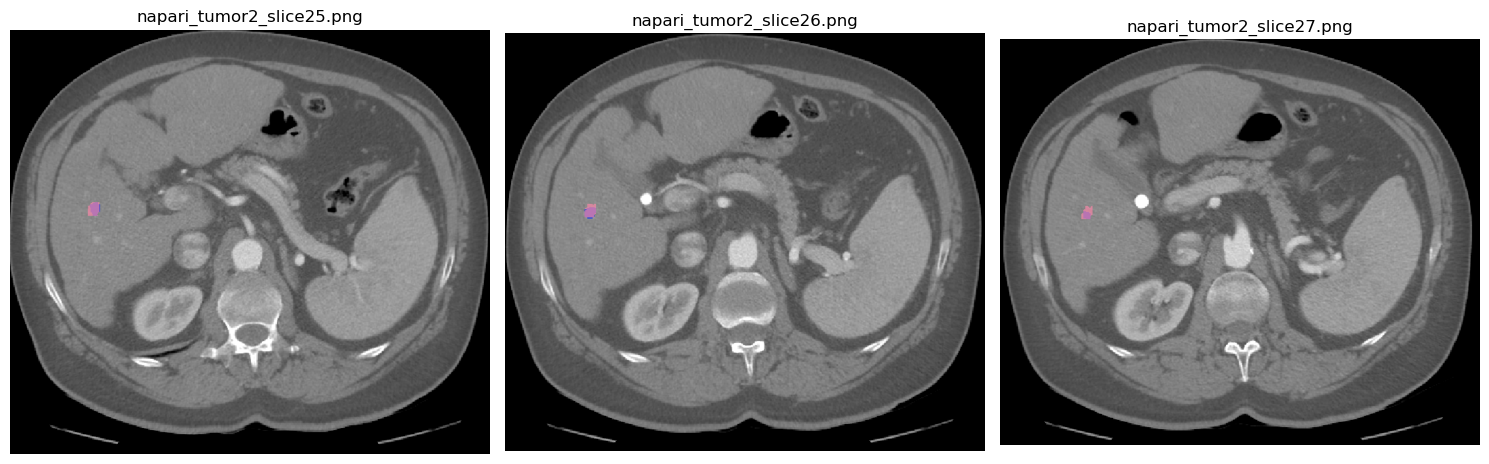

In [22]:
folder_path = 'task2_data/'
image_paths = list(Path(folder_path).glob('*.png'))  

group_pattern = [4, 3, 3,3]
groups = []
start_idx = 0

for count in group_pattern:
    end_idx = start_idx + count
    groups.append(image_paths[start_idx:end_idx])
    start_idx = end_idx

for group in groups:
    plt.figure(figsize=(15, 5))
    
    for idx, img_path in enumerate(group, 1):
        img = Image.open(img_path)
        
        plt.subplot(1, len(group), idx)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_path.name)
    
    plt.tight_layout()
    plt.show()

In [15]:
def create_solid_overlay_rotation_gif(volume, mask1, mask2, n_frames=36,  interval=100, output_path='animation_gif', alpha=0.5):

    # Ensure output path exists
    os.makedirs(output_path, exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 7))
    ims = []
    angle_step = 360 / n_frames

    for i in range(n_frames):
        angle = i * angle_step
        #counterclockwise rotation
        #rotation is performed in the plane formed by the second and third dimensions
        #Stablish for reference image bilinear interpolation (order=1)  for continuous data to achieve smooth interpolation
        vol_rot = ndi.rotate(volume, angle=angle, axes=(1,2), reshape=False, order=1)
        # Masks use Nearest-neighbor (order=0) preserve discrete label values
        mask1_rot = ndi.rotate(mask1, angle=angle, axes=(1,2), reshape=False, order=0)
        mask2_rot = ndi.rotate(mask2, angle=angle, axes=(1,2), reshape=False, order=0)
        # Obtain MIPs
        mip_vol = np.max(vol_rot, axis=1)
        mip1 = np.max(mask1_rot, axis=1) > 0
        mip2 = np.max(mask2_rot, axis=1) > 0
        # Prepare regions for Alpha blending
        overlap = mip1 & mip2
        only1 = mip1 & ~mip2
        only2 = mip2 & ~mip1

        # Normalize background
        mip_norm = (mip_vol - np.min(mip_vol)) / (np.ptp(mip_vol) + 1e-8)
        rgb = np.stack([mip_norm]*3, axis=-1)

        # Define colors
        color1 = np.array([1,0,0])   # Red
        color2 = np.array([1,0,1]) # Magenta
        color_overlap = np.array([0,1,0])   # Green

        # Blend overlays using alpha blending to have transparency
        # Integrate the same color blending logic across all RGB channels.
        #If a pixel belongs to more than one mask, 
        #the last applied mask in the sequence will determine the final color at that pixel.
        #Let the pixel that does not belong to any mask unchange.
        # Only1
        for c in range(3):
            rgb[...,c] = np.where(
                only1,
                (1 - alpha) * rgb[...,c] + alpha * color1[c],
                rgb[...,c]
            )
        # Only2
        for c in range(3):
            rgb[...,c] = np.where(
                only2,
                (1 - alpha) * rgb[...,c] + alpha * color2[c],
                rgb[...,c]
            )
        # Overlap
        for c in range(3):
            rgb[...,c] = np.where(
                overlap,
                (1 - alpha) * rgb[...,c] + alpha * color_overlap[c],
                rgb[...,c]
            )

        # For animation 
        # Avoiding out of range colors.
        img = ax.imshow(rgb, animated=True, aspect=aspect_ratio_coronal)
        title = ax.text(
            0.5, 1.01, f'Overlay - Angle {int(angle)}°', color='black',
            ha='center', va='bottom', transform=ax.transAxes, fontsize=10
        )
        ims.append([img, title])

    ax.axis('off')
    plt.tight_layout()
    ani = animation.ArtistAnimation(fig, ims, interval=interval, blit=True)
    gif_path = os.path.join(output_path, 'Segmented.gif')
    ani.save(gif_path, writer='pillow')
    plt.close(fig)
    return ani   

ani=create_solid_overlay_rotation_gif(ct_images, individuals_mask[1], segmentations[1],n_frames=36, interval=250)

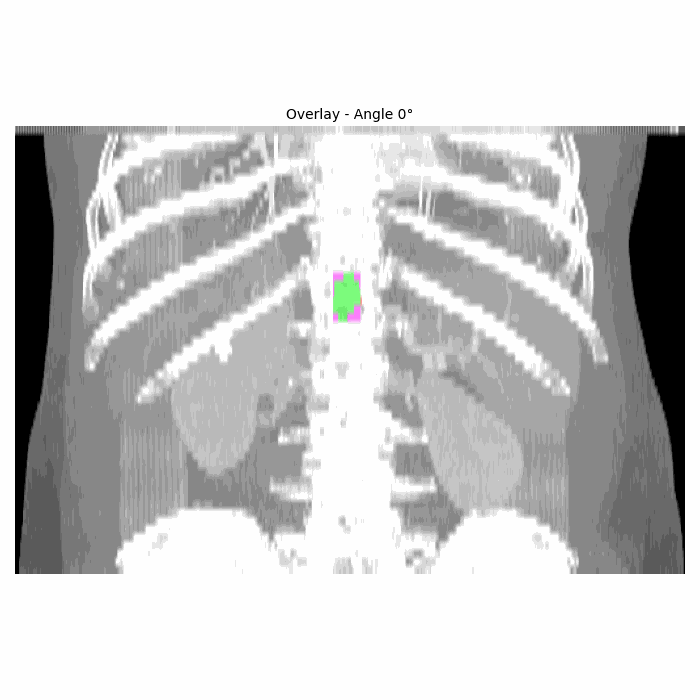

In [16]:
# Show
from IPython.display import Image
gif_path = os.path.join('animation_gif', 'Segmented.gif')
display(Image(filename=gif_path))

---

Numerical metrics comparing the ground truth vs segmented tumor.  

Cannot calculate AUC, no prediction probabilities, not just binary masks.
Metrics:
- Dice: Measures the similarity between two sets, 1 matches completely.
- IoU: Degree of overlap between prediction and reference, is the intersection divided by the union of both sets, 1 total total overlap.
- Sensitivity: True positives among the real positives, 1 all real cases are dectected.
- Specificity: True negatives from among the real negatives, 1 dectect all real cases.
- Accuracy: Correct predictions (both positive and negative) out of the total number of cases evaluated, 1 classifies all cases correctly.
- Cohen's Kappa: Better or worse than chance, 1 is perfect agreement, 0 is no better than chance.
- F1 score: Harmonic mean between accuracy and sensitivity, 0 underperforms one of the 2.

In [17]:
def calculate_segmentation_metrics(ground_truth, tumor_mask):

    if tumor_mask.dtype == np.bool_:
        tumor_mask = tumor_mask.astype(int)
    
    # Ensure that they are binary arrays
    ground_truth = ground_truth > 0
    tumor_mask = tumor_mask > 0
    
    # Calculate areas of overlap
    intersection = np.logical_and(ground_truth, tumor_mask)
    union = np.logical_or(ground_truth, tumor_mask)
    
    # Calculate metrics
    true_positive = np.sum(intersection)
    false_positive = np.sum(tumor_mask) - true_positive
    false_negative = np.sum(ground_truth) - true_positive
    # Total number of pixels
    total_pixels = ground_truth.size

    # True Negatives
    true_negative = total_pixels - (true_positive + false_positive + false_negative)
    
    # Metrics
    dice = 2 * true_positive / (2 * true_positive + false_positive + false_negative) if true_positive > 0 else 0
    iou = true_positive / np.sum(union) if np.sum(union) > 0 else 0
    sensitivity_recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
    # Coeficiente de Kappa (Cohen's Kappa)
    kappa = cohen_kappa_score(ground_truth.flatten(), tumor_mask.flatten())
    # F1 Score
    f1 = f1_score(ground_truth.flatten(), tumor_mask.flatten())

    return {
        'Dice': dice,
        'IoU': iou,
        'Sensitivity': sensitivity_recall,
        'Specificity':specificity,
        'Precision': precision,
        'Cohen\'s Kappa': kappa,
        'F1 score':f1
    }

In [18]:
metrics=[]
for i in range(len(individuals_mask)):
    metrics.append(calculate_segmentation_metrics(individuals_mask[i],segmentations[i]))
    print(f'\nTumor {i} segmentation assessment metrics:')
    metrics2=metrics[i]
    for metric, value in metrics2.items():
        print(f'{metric}: {value:.4f}')


Tumor 0 segmentation assessment metrics:
Dice: 0.6819
IoU: 0.5174
Sensitivity: 0.9304
Specificity: 1.0000
Precision: 0.5382
Cohen's Kappa: 0.6819
F1 score: 0.6819

Tumor 1 segmentation assessment metrics:
Dice: 0.6069
IoU: 0.4357
Sensitivity: 0.9640
Specificity: 0.9999
Precision: 0.4429
Cohen's Kappa: 0.6069
F1 score: 0.6069

Tumor 2 segmentation assessment metrics:
Dice: 0.7578
IoU: 0.6101
Sensitivity: 0.9350
Specificity: 1.0000
Precision: 0.6371
Cohen's Kappa: 0.7578
F1 score: 0.7578


The metrics obtained are consistent with the visualization of the results, i.e. the results tend to be more FP, due to the fact that in medical diagnostics it is better to have FP than to have FN. In some slices it covers the whole tumor, but in addition to that, a lot of pixels are added as FP. But in the slices that the ground truth decreases quite a lot in size, this is not detected by the method, so it is necessary to improve in this case, this case is a FN. So the trend of the results these metrics will have low value: Dice & IoU, Sensitivity (Recall), Cohen's Kappa, F1 Score. With high values: Specificity.